# 08. Interrupted Time Series

Interrupted time series, usually abbreviated ITS, is a quasi-experimental design for evaluating an intervention introduced at a clearly defined point in time. Instead of comparing treated and untreated units, the basic ITS design compares the post-intervention trajectory to the trajectory expected from the pre-intervention trend.

This design is common in industry because many interventions happen system-wide: a pricing rule changes, a fraud model launches, a marketplace policy goes live, a support workflow is replaced, a ranking algorithm is updated, or a compliance requirement begins on a known date.

ITS is strongest when we have many observations before and after the intervention, a stable measurement process, a well-defined intervention date, and careful modeling of secular trends, seasonality, and autocorrelation.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain when interrupted time series is appropriate.
- Distinguish level changes from slope changes.
- Fit a segmented regression model.
- Build and interpret a counterfactual continuation of the pre-intervention trend.
- Diagnose seasonality and autocorrelation.
- Use HAC standard errors for serially correlated residuals.
- Run sensitivity checks with alternative interruption dates.
- Extend ITS to a controlled interrupted time series with a comparison series.
- Translate an ITS result into an industry decision readout.

## Mathematical Setup: Counterfactual Trend and Breaks

Interrupted time series asks whether the post-intervention series departs from the counterfactual continuation of the pre-intervention trend. With intervention time $T_0$, define:

$$
Post_t = 1[t \ge T_0]
$$

$$
TimeAfter_t = (t-T_0+1)Post_t
$$

The segmented regression model is:

$$
Y_t = \beta_0 + \beta_1t + \beta_2Post_t + \beta_3TimeAfter_t + \epsilon_t
$$

Here $\beta_2$ is an immediate level change and $\beta_3$ is a slope change. The post-period counterfactual without the intervention is:

$$
\widehat{Y}_{t,0} = \widehat{\beta}_0 + \widehat{\beta}_1t
$$

A controlled ITS adds a comparison series and estimates whether the treated series breaks more than the control series. That design is stronger when the control series shares shocks and seasonality with the treated series.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def add_season_terms(frame, period=12, harmonics=2):
    """Add sine and cosine seasonal terms to an ITS design matrix.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        period: Seasonal period length used for sine and cosine terms.
        harmonics: Number of seasonal sine/cosine harmonics to add.

    Returns:
        pandas.DataFrame: Frame with seasonal sine and cosine columns.
    """
    work = frame.copy()
    for k in range(1, harmonics + 1):
        work[f"sin{k}"] = np.sin(2 * np.pi * k * work["t"] / period)
        work[f"cos{k}"] = np.cos(2 * np.pi * k * work["t"] / period)
    return work


def add_its_terms(frame, intervention_month):
    """Add post-intervention and time-after-intervention variables for segmented ITS.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        intervention_month: Time index at which the intervention begins.

    Returns:
        pandas.DataFrame: Frame with segmented ITS treatment terms.
    """
    work = frame.copy()
    work["post"] = (work["t"] >= intervention_month).astype(int)
    work["time_after"] = np.where(work["t"] >= intervention_month, work["t"] - intervention_month + 1, 0)
    return work


def fit_segmented_its(frame, outcome, intervention_month, include_season=True, hac_lags=12):
    """Fit a segmented ITS regression with optional seasonality and HAC uncertainty.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        outcome: Outcome variable name or vector being analyzed.
        intervention_month: Time index at which the intervention begins.
        include_season: Whether seasonal sine/cosine terms are included in the ITS model.
        hac_lags: Maximum lag used for HAC standard errors.

    Returns:
        dict: Segmented ITS model, conventional model, work data, and term list.
    """
    work = add_its_terms(frame, intervention_month)
    terms = ["t", "post", "time_after"]
    if include_season:
        work = add_season_terms(work)
        terms += ["sin1", "cos1", "sin2", "cos2"]

    X = sm.add_constant(work[terms], has_constant="add")
    model = sm.OLS(work[outcome], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    conventional = sm.OLS(work[outcome], X).fit()
    return {"data": work, "model": model, "conventional_model": conventional, "terms": terms}


def prediction_frame(frame, terms, intervention_month, intervention_active=True):
    """Build prediction design matrices for observed and counterfactual ITS paths.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        terms: List of model terms that define the prediction design matrix.
        intervention_month: Time index at which the intervention begins.
        intervention_active: Whether prediction uses the intervention terms or turns them off for the counterfactual.

    Returns:
        pandas.DataFrame: Design matrix for observed or counterfactual ITS prediction.
    """
    work = add_its_terms(frame, intervention_month)
    if not intervention_active:
        work["post"] = 0
        work["time_after"] = 0
    if any(term.startswith("sin") or term.startswith("cos") for term in terms):
        work = add_season_terms(work)
    X = sm.add_constant(work[terms], has_constant="add")
    return X


def coefficient_row(label, model, term):
    """Extract one coefficient into a display-ready row.

    Args:
        label: Human-readable label for the row or scenario being produced.
        model: Fitted model object whose parameters or predictions are being used.
        term: Model coefficient name to extract or report.

    Returns:
        dict: Display-ready coefficient row.
    """
    estimate = float(model.params[term])
    se = float(model.bse[term])
    return {
        "model_or_quantity": label,
        "term": term,
        "estimate": estimate,
        "std_error": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "p_value": float(model.pvalues[term]),
    }


def plot_effect_table(table, title, reference=None):
    """Plot effect estimates and uncertainty intervals for model comparisons.

    Args:
        table: Summary table containing estimates, intervals, or diagnostics.
        title: Title shown on the resulting figure.
        reference: Reference value or omitted event time used for interpretation.

    Returns:
        tuple: Matplotlib figure and axes containing effect estimates.
    """
    plot_table = table.dropna(subset=["estimate"]).copy().reset_index(drop=True)
    y = np.arange(len(plot_table))
    fig, ax = plt.subplots(figsize=(9, max(3.6, 0.55 * len(plot_table) + 1.4)))
    for i, row in plot_table.iterrows():
        if np.isfinite(row.get("ci_low", np.nan)) and np.isfinite(row.get("ci_high", np.nan)):
            ax.errorbar(
                row["estimate"],
                y[i],
                xerr=[[row["estimate"] - row["ci_low"]], [row["ci_high"] - row["estimate"]]],
                fmt="o",
                capsize=4,
                color="#2563eb",
                ecolor="#93c5fd",
            )
        else:
            ax.scatter(row["estimate"], y[i], color="#2563eb", s=45)
    if reference is not None:
        ax.axvline(reference, color="#16a34a", linestyle="--", linewidth=1.5, label="Reference")
        ax.legend()
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_table["model_or_quantity"])
    ax.invert_yaxis()
    ax.set_xlabel("Estimated effect")
    ax.set_title(title)
    return fig, ax

## 1. Where ITS Fits

ITS is useful when an intervention happens at a known time and randomization is unavailable. Wagner et al. (2002) describe segmented regression as a standard approach for estimating intervention effects in ITS studies. Bernal et al. (2016) emphasize that ITS is especially valuable for population-level interventions implemented at a clearly defined point in time.

Industry examples:

- A fraud-screening rule launches for the whole marketplace.
- A support automation workflow is deployed globally.
- A pricing fee change starts on a known date.
- A ranking algorithm changes for all users in a region.
- A compliance policy takes effect after a regulatory deadline.
- A data-quality rule changes the way events are recorded.

ITS asks whether the post-intervention path departs from the path implied by the pre-intervention trajectory.

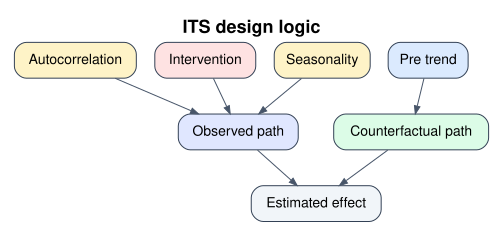

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
make_dag(
    edges=[
        ("Pre trend", "Counterfactual path"),
        ("Seasonality", "Observed path"),
        ("Autocorrelation", "Observed path"),
        ("Intervention", "Observed path"),
        ("Observed path", "Estimated effect"),
        ("Counterfactual path", "Estimated effect"),
    ],
    title="ITS design logic",
    node_colors={
        "Pre trend": "#dbeafe",
        "Counterfactual path": "#dcfce7",
        "Seasonality": "#fef3c7",
        "Autocorrelation": "#fef3c7",
        "Intervention": "#fee2e2",
        "Observed path": "#e0e7ff",
        "Estimated effect": "#f1f5f9",
    },
    rankdir="TB",
)

ITS is not simply a before/after comparison. The design uses multiple pre-intervention observations to estimate what would have happened after the intervention if the prior trajectory had continued.

## 2. Segmented Regression Model

A basic segmented regression model is:

$$
Y_t = \beta_0 + \beta_1t + \beta_2Post_t + \beta_3TimeAfter_t + \epsilon_t
$$

where:

- $t$ is the time index.
- $Post_t$ is 0 before the intervention and 1 after the intervention.
- $TimeAfter_t$ is 0 before the intervention and counts time since the intervention afterward.
- $\beta_2$ is the immediate level change.
- $\beta_3$ is the slope change after the intervention.

For monthly business data, we often add seasonal terms:

$$
Y_t = \beta_0 + \beta_1t + \beta_2Post_t + \beta_3TimeAfter_t + \gamma_1\sin(2\pi t / 12) + \gamma_2\cos(2\pi t / 12) + \epsilon_t
$$

The causal claim is that no other time-varying shock at the intervention date explains the break in the series.

## 3. Running Example: Fraud Review Policy

Suppose a marketplace launches a new fraud-review policy at month 43. The outcome is chargebacks per 10,000 orders. Lower is better.

The policy is expected to have:

- an immediate level reduction because the most obvious risky transactions are blocked quickly;
- a gradual slope reduction because model monitoring and investigation workflows improve over time.

We simulate 72 months of data: 42 months before launch and 30 months after launch. We also simulate a control marketplace that shares seasonality and market shocks but does not receive the policy.

**Dataset and experiment setup.** The ITS dataset represents a monthly marketplace metric before and after a fraud-review policy launch. The treated series is chargebacks per 10,000 orders, and a control marketplace is generated to share some calendar shocks without receiving the policy. The simulation includes a pre-existing trend, seasonality, autocorrelation, an immediate level change, and a gradual slope change. This is more realistic than a flat before/after example because operational time series often move for many reasons at once. The known intervention effect lets the notebook check whether segmented regression recovers the intended post-launch deviation.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_its_data(n_months=72, intervention_month=42, seed=8808):
    """Generate the synthetic its data data used in 08. Interrupted Time Series.

    Args:
        n_months: Number of monthly observations to generate.
        intervention_month: Time index at which the intervention begins.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)
    rows = []

    common_shock = np.zeros(n_months)
    shock_prev = 0.0
    for t in range(n_months):
        shock_prev = 0.55 * shock_prev + rng.normal(0, 1.2)
        common_shock[t] = shock_prev

    for series in ["Treated marketplace", "Control marketplace"]:
        is_treated = series == "Treated marketplace"
        local_prev = 0.0
        for t in range(n_months):
            month = t + 1
            date = pd.Timestamp("2020-01-01") + pd.DateOffset(months=t)
            post = int(t >= intervention_month)
            time_after = max(0, t - intervention_month + 1)

            season = 4.0 * np.sin(2 * np.pi * t / 12) + 2.0 * np.cos(2 * np.pi * t / 12)
            baseline = 92 - 0.22 * t + season + common_shock[t]
            if not is_treated:
                baseline = 85 - 0.18 * t + 0.85 * season + 0.90 * common_shock[t]

            true_policy_effect = 0.0
            if is_treated:
                true_policy_effect = -8.0 * post - 0.28 * time_after

            local_prev = 0.45 * local_prev + rng.normal(0, 1.6)
            outcome = baseline + true_policy_effect + local_prev

            rows.append(
                {
                    "series": series,
                    "month": month,
                    "date": date,
                    "t": t,
                    "post": post,
                    "time_after": time_after,
                    "chargebacks_per_10k": outcome,
                    "true_policy_effect": true_policy_effect,
                }
            )

    return pd.DataFrame(rows)


intervention_month = 42
df_its = simulate_its_data(intervention_month=intervention_month)
treated = df_its.loc[df_its["series"] == "Treated marketplace"].copy()
control = df_its.loc[df_its["series"] == "Control marketplace"].copy()

summary = (
    df_its.groupby("series")
    .agg(
        months=("month", "count"),
        pre_months=("post", lambda s: int((s == 0).sum())),
        post_months=("post", lambda s: int((s == 1).sum())),
        avg_chargebacks=("chargebacks_per_10k", "mean"),
    )
)
smart_display(summary.round(3))

,months,pre_months,post_months,avg_chargebacks
series,,,,
Control marketplace,72,42,30,79.243
Treated marketplace,72,42,30,79.510


In Running Example: Fraud Review Policy, the table checks pre-intervention fit before any post-period gap is interpreted. Good pre-intervention fit is what makes the post-launch gap interpretable.

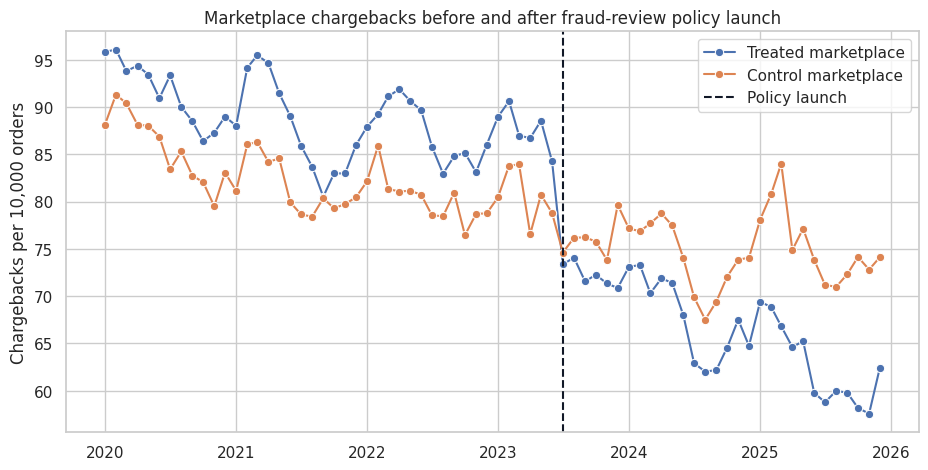

In [5]:
# Build the Running Example: Fraud Review Policy plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(11, 5.2))
policy_date = treated.loc[treated["t"] == intervention_month, "date"].iloc[0]
sns.lineplot(data=df_its, x="date", y="chargebacks_per_10k", hue="series", marker="o", ax=ax)
ax.axvline(policy_date, color="#111827", linestyle="--", linewidth=1.5, label="Policy launch")
ax.set_title("Marketplace chargebacks before and after fraud-review policy launch")
ax.set_xlabel("")
ax.set_ylabel("Chargebacks per 10,000 orders")
ax.legend(title="", frameon=True)
plt.show()

The treated marketplace is improving before launch because fraud operations were already maturing. A plain before/after comparison would confuse this pre-existing trend with the policy effect.

## 4. Naive Before/After Is Not ITS

A simple before/after average ignores trend and seasonality. It answers:

> Were average chargebacks lower after launch than before launch?

That differs from:

> Did chargebacks fall below the level expected from the pre-launch trend?

In [6]:
# Assemble the Naive Before/After Is Not ITS summary table used for interpretation.
naive_before_after = (
    treated.loc[treated["post"] == 1, "chargebacks_per_10k"].mean()
    - treated.loc[treated["post"] == 0, "chargebacks_per_10k"].mean()
)

naive_table = pd.DataFrame(
    {
        "quantity": ["Pre average", "Post average", "Naive post - pre"],
        "value": [
            treated.loc[treated["post"] == 0, "chargebacks_per_10k"].mean(),
            treated.loc[treated["post"] == 1, "chargebacks_per_10k"].mean(),
            naive_before_after,
        ],
    }
)
smart_display(naive_table.round(3))

,quantity,value
0,Pre average,88.764
1,Post average,66.553
2,Naive post - pre,-22.211


In Naive Before/After Is Not ITS, the table checks whether the instrument creates useful variation and whether the exclusion story is plausible. First-stage strength and the exclusion story carry the causal interpretation.

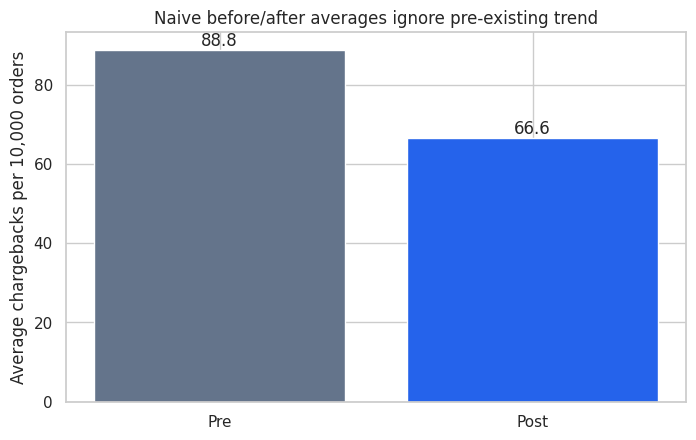

In [7]:
# Build the Naive Before/After Is Not ITS plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(8, 4.8))
period_means = treated.assign(period=np.where(treated["post"] == 1, "Post", "Pre")).groupby("period")["chargebacks_per_10k"].mean().reindex(["Pre", "Post"])
ax.bar(period_means.index, period_means.values, color=["#64748b", "#2563eb"])
ax.set_title("Naive before/after averages ignore pre-existing trend")
ax.set_ylabel("Average chargebacks per 10,000 orders")
for i, value in enumerate(period_means.values):
    ax.text(i, value + 1, f"{value:.1f}", ha="center")
plt.show()

In Naive Before/After Is Not ITS, the figure keeps attention on the neighborhood around the cutoff. The local contrast earns trust through bandwidth, covariate, density, and placebo checks.

The naive estimate is often too dramatic when the outcome was already trending in the desired direction. ITS models the pre-intervention path directly.

## 5. Fit Segmented Regression

We fit a segmented regression with time, post indicator, time after intervention, and seasonal sine/cosine terms. We use heteroskedasticity and autocorrelation consistent standard errors because monthly observations are often serially correlated.

In [8]:
# Assemble the Fit Segmented Regression summary table used for interpretation.
segmented = fit_segmented_its(
    treated,
    outcome="chargebacks_per_10k",
    intervention_month=intervention_month,
    include_season=True,
    hac_lags=12,
)
segmented_model = segmented["model"]

segmented_table = pd.DataFrame(
    [
        coefficient_row("Immediate level change", segmented_model, "post"),
        coefficient_row("Monthly slope change", segmented_model, "time_after"),
    ]
)
smart_display(segmented_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,Immediate level change,post,-9.750,0.948,-11.609,-7.891,0.000
1,Monthly slope change,time_after,-0.336,0.050,-0.433,-0.238,0.000


In Fit Segmented Regression, the coefficients describe level and slope changes relative to the pre-intervention path. The causal reading depends on whether the timing really isolates the intervention from seasonality and coincident shocks.

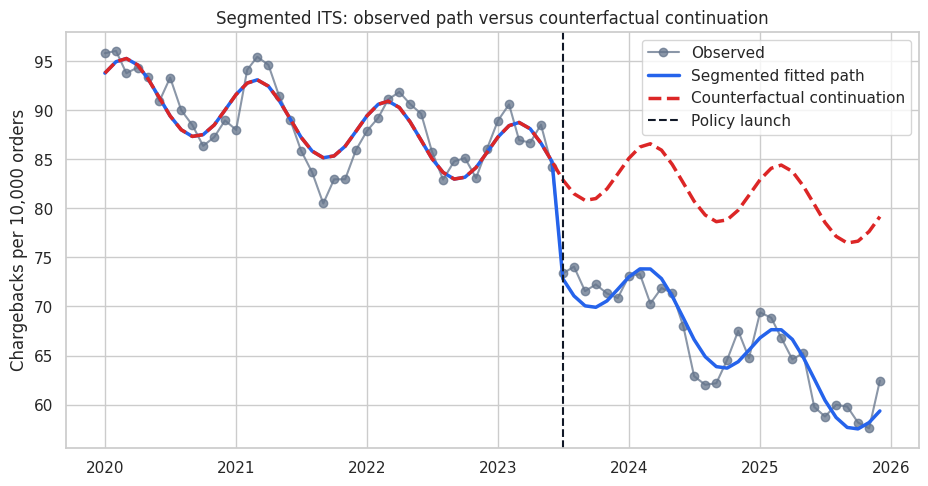

In [9]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
observed_X = prediction_frame(treated, segmented["terms"], intervention_month, intervention_active=True)
counterfactual_X = prediction_frame(treated, segmented["terms"], intervention_month, intervention_active=False)

treated_plot = treated.copy()
treated_plot["fitted"] = segmented_model.predict(observed_X)
treated_plot["counterfactual"] = segmented_model.predict(counterfactual_X)
treated_plot["estimated_effect"] = treated_plot["fitted"] - treated_plot["counterfactual"]

fig, ax = plt.subplots(figsize=(11, 5.4))
policy_date = treated_plot.loc[treated_plot["t"] == intervention_month, "date"].iloc[0]
ax.plot(treated_plot["date"], treated_plot["chargebacks_per_10k"], marker="o", color="#64748b", alpha=0.75, label="Observed")
ax.plot(treated_plot["date"], treated_plot["fitted"], color="#2563eb", linewidth=2.5, label="Segmented fitted path")
ax.plot(treated_plot["date"], treated_plot["counterfactual"], color="#dc2626", linestyle="--", linewidth=2.5, label="Counterfactual continuation")
ax.axvline(policy_date, color="#111827", linestyle="--", linewidth=1.5, label="Policy launch")
ax.set_title("Segmented ITS: observed path versus counterfactual continuation")
ax.set_xlabel("")
ax.set_ylabel("Chargebacks per 10,000 orders")
ax.legend(frameon=True)
plt.show()

The vertical gap between the fitted observed path and the counterfactual continuation is the estimated policy effect. The gap can grow over time if the slope changes after the intervention.

In [10]:
# Build the summary table used to connect the calculation back to the design question.
post_effects = treated_plot.loc[treated_plot["post"] == 1, ["date", "month", "estimated_effect", "true_policy_effect"]].copy()
effect_summary = pd.DataFrame(
    {
        "quantity": [
            "Estimated immediate effect",
            "True immediate effect in simulation",
            "Estimated effect at final month",
            "True effect at final month in simulation",
            "Average estimated post effect",
            "Average true post effect in simulation",
        ],
        "value": [
            post_effects["estimated_effect"].iloc[0],
            post_effects["true_policy_effect"].iloc[0],
            post_effects["estimated_effect"].iloc[-1],
            post_effects["true_policy_effect"].iloc[-1],
            post_effects["estimated_effect"].mean(),
            post_effects["true_policy_effect"].mean(),
        ],
    }
)
smart_display(effect_summary.round(3))

,quantity,value
0,Estimated immediate effect,-10.086000
1,True immediate effect in simulation,-8.280000
2,Estimated effect at final month,-19.821000
3,True effect at final month in simulation,-16.400000
4,Average estimated post effect,-14.953000
5,Average true post effect in simulation,-12.340000


In Fit Segmented Regression, the table compares the observed series with a counterfactual time path. Time-series structure can turn an ordinary before-after break into a tempting but weak causal story.

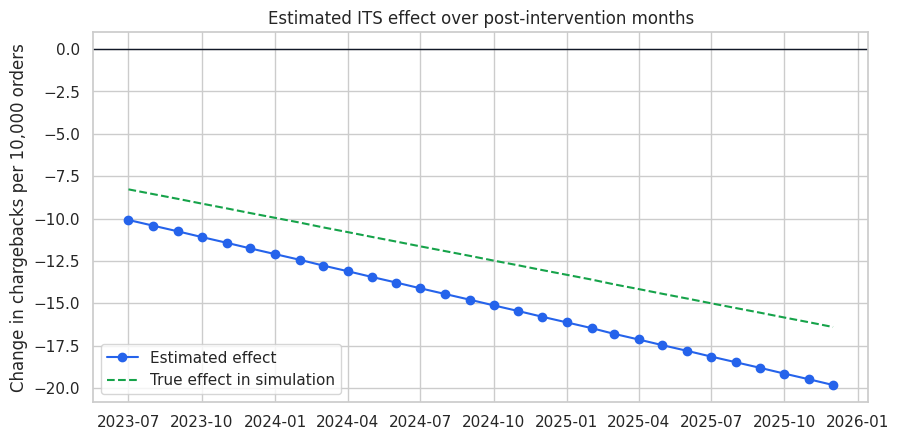

In [11]:
# Build the Fit Segmented Regression plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(post_effects["date"], post_effects["estimated_effect"], marker="o", color="#2563eb", label="Estimated effect")
ax.plot(post_effects["date"], post_effects["true_policy_effect"], linestyle="--", color="#16a34a", label="True effect in simulation")
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Estimated ITS effect over post-intervention months")
ax.set_xlabel("")
ax.set_ylabel("Change in chargebacks per 10,000 orders")
ax.legend()
plt.show()

In real data, there is no true policy-effect column. We include it here only to verify that the estimator is learning the intended simulated signal.

## 6. Seasonality Matters

Monthly business metrics often have seasonal structure. If seasonality is correlated with the intervention date, a model without seasonal controls may attribute seasonal movement to the intervention.

In [12]:
# Assemble the Seasonality Matters summary table used for interpretation.
segmented_no_season = fit_segmented_its(
    treated,
    outcome="chargebacks_per_10k",
    intervention_month=intervention_month,
    include_season=False,
    hac_lags=12,
)

season_comparison = pd.DataFrame(
    [
        coefficient_row("No seasonality: level change", segmented_no_season["model"], "post"),
        coefficient_row("With seasonality: level change", segmented_model, "post"),
        coefficient_row("No seasonality: slope change", segmented_no_season["model"], "time_after"),
        coefficient_row("With seasonality: slope change", segmented_model, "time_after"),
    ]
)
smart_display(season_comparison.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,No seasonality: level change,post,-10.490000,1.112000,-12.669000,-8.312000,0.000000
1,With seasonality: level change,post,-9.750000,0.948000,-11.609000,-7.891000,0.000000
2,No seasonality: slope change,time_after,-0.332000,0.048000,-0.428000,-0.237000,0.000000
3,With seasonality: slope change,time_after,-0.336000,0.050000,-0.433000,-0.238000,0.000000


In Seasonality Matters, the output should be judged by whether seasonal structure has been handled before interpreting the intervention break. A seasonal pattern can otherwise masquerade as a policy effect.

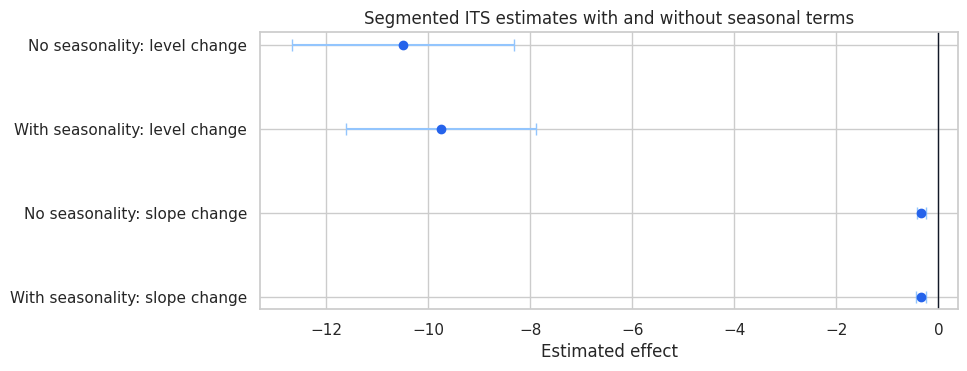

In [13]:
plot_effect_table(
    season_comparison,
    title="Segmented ITS estimates with and without seasonal terms",
)
plt.show()

In Seasonality Matters, the figure compares the observed series with a counterfactual time path. The model has to separate intervention timing from seasonality, shocks, and serial dependence.

Seasonality controls do not make ITS causal by themselves. They keep predictable calendar patterns from being mistaken for treatment effects.

## 7. Autocorrelation and Standard Errors

Time series residuals are often correlated. If residuals are autocorrelated and we use ordinary regression standard errors, uncertainty can be understated. Bernal et al. (2016) recommend checking residual autocorrelation and using methods such as autoregressive models or other corrections when needed.

Here we compare conventional OLS standard errors with HAC standard errors.

In [14]:
# Build the summary table used to connect the calculation back to the design question.
conventional_model = segmented["conventional_model"]
se_comparison = pd.DataFrame(
    [
        {
            "term": "post",
            "estimate": segmented_model.params["post"],
            "conventional_se": conventional_model.bse["post"],
            "hac_se": segmented_model.bse["post"],
        },
        {
            "term": "time_after",
            "estimate": segmented_model.params["time_after"],
            "conventional_se": conventional_model.bse["time_after"],
            "hac_se": segmented_model.bse["time_after"],
        },
    ]
)
smart_display(se_comparison.round(3))

,term,estimate,conventional_se,hac_se
0,post,-9.750,0.981,0.948
1,time_after,-0.336,0.050,0.050


In Autocorrelation and Standard Errors, read the model output with the error structure in mind. Serial correlation can make an effect look more precise than the time series really supports.

In [15]:
# Assemble the Autocorrelation and Standard Errors summary table used for interpretation.
residuals = segmented_model.resid
ljung_box = acorr_ljungbox(residuals, lags=[1, 3, 6, 12], return_df=True)
diagnostic_table = pd.DataFrame(
    {
        "diagnostic": ["Durbin-Watson"] + [f"Ljung-Box lag {lag}" for lag in ljung_box.index],
        "value": [durbin_watson(residuals)] + ljung_box["lb_stat"].tolist(),
        "p_value": [np.nan] + ljung_box["lb_pvalue"].tolist(),
    }
)
smart_display(diagnostic_table.round(3))

,diagnostic,value,p_value
0,Durbin-Watson,1.118,NaN
1,Ljung-Box lag 1,12.915,0.000
2,Ljung-Box lag 3,14.970,0.002
3,Ljung-Box lag 6,23.907,0.001
4,Ljung-Box lag 12,24.950,0.015


In Autocorrelation and Standard Errors, read the model output with the error structure in mind. Serial correlation can make an effect look more precise than the time series really supports.

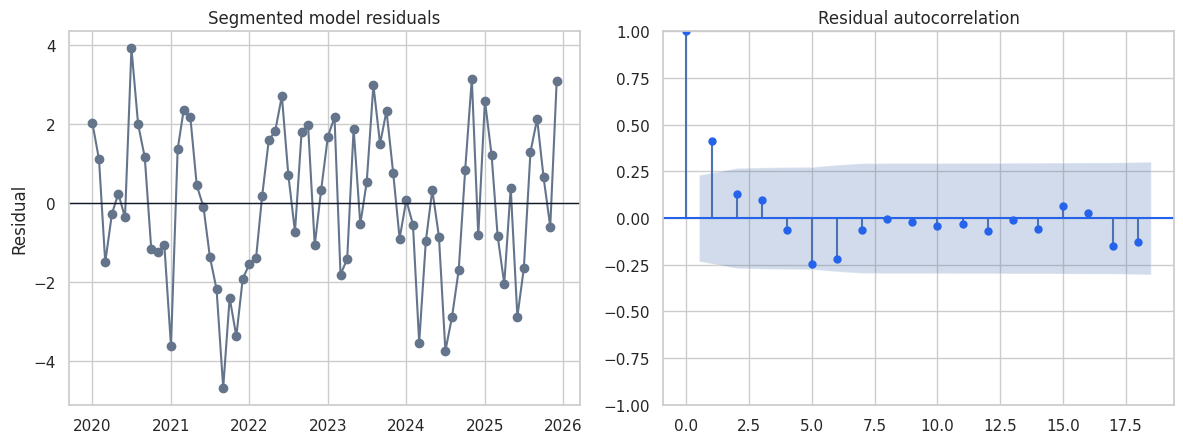

In [16]:
# Build the Autocorrelation and Standard Errors plot from the quantities computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(treated_plot["date"], residuals, marker="o", color="#64748b")
axes[0].axhline(0, color="#111827", linewidth=1)
axes[0].set_title("Segmented model residuals")
axes[0].set_xlabel("")
axes[0].set_ylabel("Residual")

plot_acf(residuals, lags=18, ax=axes[1], color="#2563eb")
axes[1].set_title("Residual autocorrelation")
plt.tight_layout()
plt.show()

The aim is to avoid pretending that serially correlated monthly data contain as much independent information as unrelated observations.

## 8. Placebo Interruption Dates

A useful falsification check is to move the intervention date to fake pre-intervention dates. If the model finds large breaks at many placebo dates, the series may have unstable dynamics unrelated to the intervention.

In [17]:
# Assemble the Placebo Interruption Dates summary table used for interpretation.
placebo_months = [18, 24, 30, 36]
placebo_rows = []
for fake_month in placebo_months:
    pre_only = treated.loc[treated["t"] < intervention_month].copy()
    placebo_fit = fit_segmented_its(
        pre_only,
        outcome="chargebacks_per_10k",
        intervention_month=fake_month,
        include_season=True,
        hac_lags=6,
    )
    row = coefficient_row(f"Fake interruption at month {fake_month + 1}", placebo_fit["model"], "post")
    row["fake_month"] = fake_month + 1
    placebo_rows.append(row)

placebo_table = pd.DataFrame(placebo_rows)
smart_display(placebo_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value,fake_month
0,Fake interruption at month 19,post,-2.285000,1.045000,-4.333000,-0.236000,0.029000,19
1,Fake interruption at month 25,post,2.398000,0.969000,0.499000,4.297000,0.013000,25
2,Fake interruption at month 31,post,2.841000,1.819000,-0.725000,6.406000,0.118000,31
3,Fake interruption at month 37,post,2.140000,0.989000,0.203000,4.078000,0.030000,37


In Placebo Interruption Dates, the output is a falsification check. A large placebo break would suggest that the model is finding structure in the time series rather than the intervention.

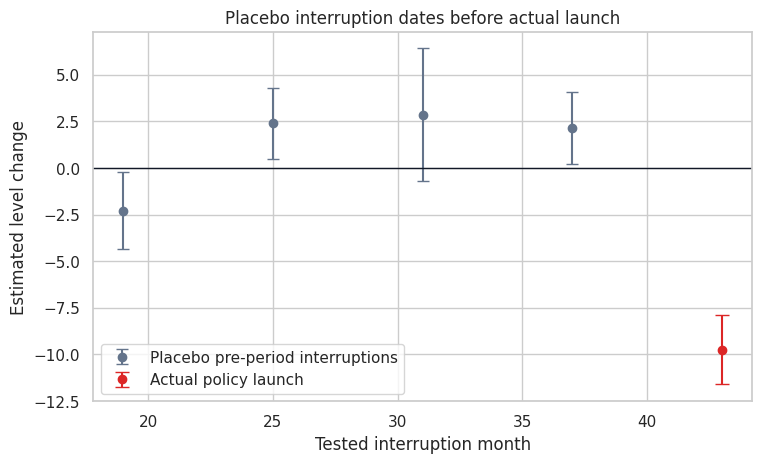

In [18]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.errorbar(
    placebo_table["fake_month"],
    placebo_table["estimate"],
    yerr=1.96 * placebo_table["std_error"],
    fmt="o",
    capsize=4,
    color="#64748b",
    label="Placebo pre-period interruptions",
)
ax.errorbar(
    [intervention_month + 1],
    [segmented_model.params["post"]],
    yerr=[1.96 * segmented_model.bse["post"]],
    fmt="o",
    capsize=5,
    color="#dc2626",
    label="Actual policy launch",
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Placebo interruption dates before actual launch")
ax.set_xlabel("Tested interruption month")
ax.set_ylabel("Estimated level change")
ax.legend()
plt.show()

In Placebo Interruption Dates, the figure compares the observed series with a counterfactual time path. Seasonality, coincident shocks, and autocorrelation can make a before-after change look more causal than it is.

Placebo tests are not formal proof. They are stress tests for the story that the observed break is special to the actual intervention date.

## 9. Phase-In Windows

Many interventions do not turn on instantly. Fraud-review policies, support workflows, and ML systems may have a launch window where teams are still ramping. One practical sensitivity check is to exclude the phase-in months immediately after launch.

In [19]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def fit_with_phase_in_gap(frame, outcome, intervention_month, gap_months):
    """Refit ITS after excluding early post-launch phase-in months.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        outcome: Outcome variable name or vector being analyzed.
        intervention_month: Time index at which the intervention begins.
        gap_months: Number of post-launch transition months omitted from the ITS fit.

    Returns:
        pandas.DataFrame: Coefficient rows after excluding phase-in months.
    """
    work = frame.loc[~frame["t"].between(intervention_month, intervention_month + gap_months - 1)].copy()
    work = work.reset_index(drop=True)
    return fit_segmented_its(work, outcome, intervention_month, include_season=True, hac_lags=12)

phase_rows = []
for gap in [0, 1, 2, 3, 4]:
    if gap == 0:
        fitted = segmented
    else:
        fitted = fit_with_phase_in_gap(treated, "chargebacks_per_10k", intervention_month, gap)
    row_level = coefficient_row(f"Exclude {gap} phase-in months: level", fitted["model"], "post")
    row_slope = coefficient_row(f"Exclude {gap} phase-in months: slope", fitted["model"], "time_after")
    row_level["gap_months"] = gap
    row_slope["gap_months"] = gap
    phase_rows.extend([row_level, row_slope])

phase_table = pd.DataFrame(phase_rows)
smart_display(phase_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value,gap_months
0,Exclude 0 phase-in months: level,post,-9.750000,0.948000,-11.609000,-7.891000,0.000000,0
1,Exclude 0 phase-in months: slope,time_after,-0.336000,0.050000,-0.433000,-0.238000,0.000000,0
2,Exclude 1 phase-in months: level,post,-9.834000,1.015000,-11.822000,-7.845000,0.000000,1
3,Exclude 1 phase-in months: slope,time_after,-0.332000,0.054000,-0.438000,-0.225000,0.000000,1
4,Exclude 2 phase-in months: level,post,-10.350000,0.929000,-12.171000,-8.528000,0.000000,2
5,Exclude 2 phase-in months: slope,time_after,-0.306000,0.048000,-0.400000,-0.211000,0.000000,2
6,Exclude 3 phase-in months: level,post,-10.753000,0.859000,-12.436000,-9.069000,0.000000,3
7,Exclude 3 phase-in months: slope,time_after,-0.286000,0.045000,-0.375000,-0.197000,0.000000,3
8,Exclude 4 phase-in months: level,post,-11.454000,0.659000,-12.746000,-10.162000,0.000000,4
9,Exclude 4 phase-in months: slope,time_after,-0.253000,0.037000,-0.326000,-0.179000,0.000000,4


In Phase-In Windows, the output should be read as a more realistic launch story. Many operational interventions ramp up, so the model needs to separate immediate jumps from gradual changes.

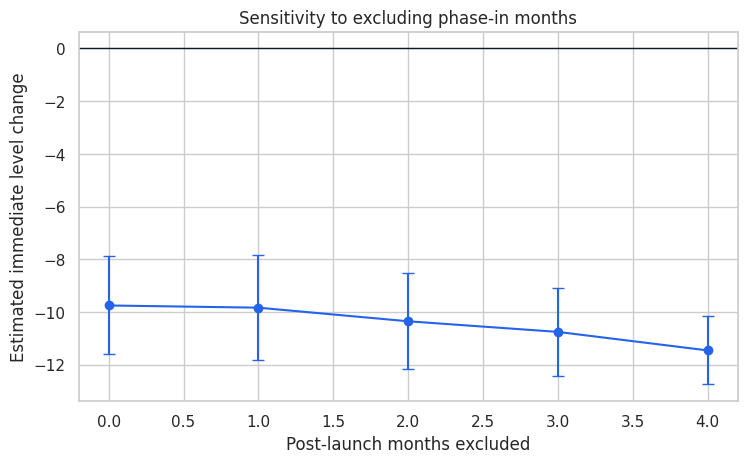

In [20]:
# Build the Phase-In Windows plot from the quantities computed above.
phase_plot = phase_table.loc[phase_table["term"] == "post"].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.errorbar(
    phase_plot["gap_months"],
    phase_plot["estimate"],
    yerr=1.96 * phase_plot["std_error"],
    fmt="o-",
    capsize=4,
    color="#2563eb",
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Sensitivity to excluding phase-in months")
ax.set_xlabel("Post-launch months excluded")
ax.set_ylabel("Estimated immediate level change")
plt.show()

If estimates are highly sensitive to excluding one or two launch months, the intervention may have a ramp-up shape that needs to be modeled explicitly.

## 10. Controlled Interrupted Time Series

A comparison series can help address time-varying shocks that affect treated and control units at the same time. Controlled ITS is especially useful when seasonality, macro shocks, measurement changes, or market-wide events may coincide with the intervention.

A simple controlled ITS model estimates the additional post-intervention level and slope change in the treated series relative to the control series.

In [21]:
# Fit the statistical model and collect estimates used in the following interpretation.
panel = df_its.copy()
panel["treated"] = (panel["series"] == "Treated marketplace").astype(int)
panel = add_its_terms(panel, intervention_month)
panel = add_season_terms(panel)
panel["treated_post"] = panel["treated"] * panel["post"]
panel["treated_time_after"] = panel["treated"] * panel["time_after"]

controlled_terms = [
    "t",
    "post",
    "time_after",
    "treated",
    "treated_post",
    "treated_time_after",
    "sin1",
    "cos1",
    "sin2",
    "cos2",
]
X_controlled = sm.add_constant(panel[controlled_terms], has_constant="add")
controlled_model = sm.OLS(panel["chargebacks_per_10k"], X_controlled).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 12},
)

controlled_table = pd.DataFrame(
    [
        coefficient_row("Controlled ITS: extra treated level change", controlled_model, "treated_post"),
        coefficient_row("Controlled ITS: extra treated slope change", controlled_model, "treated_time_after"),
    ]
)
smart_display(controlled_table.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,Controlled ITS: extra treated level change,treated_post,-8.245000,1.280000,-10.753000,-5.737000,0.000000
1,Controlled ITS: extra treated slope change,treated_time_after,-0.429000,0.060000,-0.546000,-0.311000,0.000000


In Controlled Interrupted Time Series, the model output compares the treated series with a counterfactual path informed by the control series. The estimate is strongest when the control captures the shocks that would otherwise be mistaken for treatment effects.

In [22]:
# Assemble the Controlled Interrupted Time Series summary table used for interpretation.
combined_comparison = pd.DataFrame(
    [
        coefficient_row("Single-series ITS: level change", segmented_model, "post"),
        coefficient_row("Controlled ITS: level change", controlled_model, "treated_post"),
        coefficient_row("Single-series ITS: slope change", segmented_model, "time_after"),
        coefficient_row("Controlled ITS: slope change", controlled_model, "treated_time_after"),
    ]
)
smart_display(combined_comparison.round(3))

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,Single-series ITS: level change,post,-9.750000,0.948000,-11.609000,-7.891000,0.000000
1,Controlled ITS: level change,treated_post,-8.245000,1.280000,-10.753000,-5.737000,0.000000
2,Single-series ITS: slope change,time_after,-0.336000,0.050000,-0.433000,-0.238000,0.000000
3,Controlled ITS: slope change,treated_time_after,-0.429000,0.060000,-0.546000,-0.311000,0.000000


In Controlled Interrupted Time Series, the model output compares the treated series with a counterfactual path informed by the control series. The estimate is strongest when the control captures the shocks that would otherwise be mistaken for treatment effects.

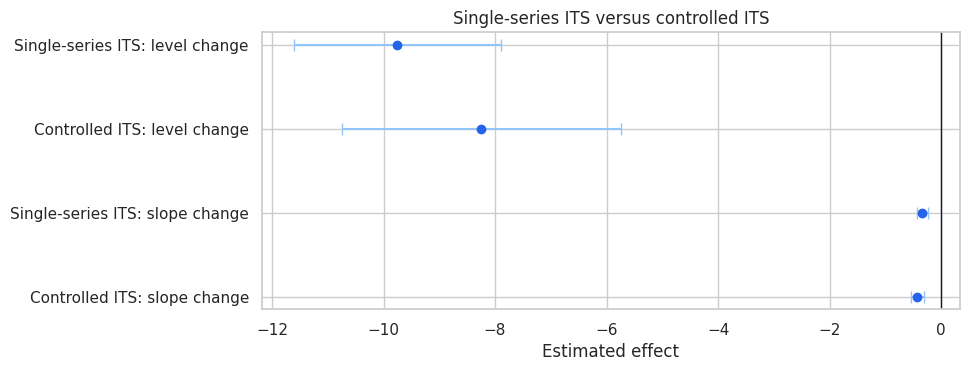

In [23]:
plot_effect_table(
    combined_comparison,
    title="Single-series ITS versus controlled ITS",
)
plt.show()

The control series is not a magic fix. It helps only if it captures the shocks that would otherwise confound the treated series and is not itself affected by the intervention.

## 11. What Can Go Wrong?

ITS is vulnerable when something else changes at the same time as the intervention.

Common threats:

- another policy launched at the same date;
- measurement or logging changed at the same date;
- seasonality was not modeled;
- the intervention date was selected after looking at the data;
- the outcome was already bending before launch;
- autocorrelation was ignored;
- the post period is too short;
- the intervention ramps gradually but the model assumes an immediate shift;
- a control series is contaminated by the treatment.

Good ITS work is as much about timeline forensics as regression.

In [24]:
# Build the summary table used to connect the calculation back to the design question.
checklist = pd.DataFrame(
    {
        "design_question": [
            "Is the intervention date known before analysis?",
            "Are there enough observations before and after?",
            "Is the measurement process stable?",
            "Are trend and seasonality modeled?",
            "Is residual autocorrelation checked?",
            "Are placebo dates tested?",
            "Is there a credible comparison series?",
            "Could another event explain the break?",
            "Is the launch immediate or phased?",
        ],
        "why_it_matters": [
            "Avoids choosing the break point after seeing the outcome.",
            "ITS needs enough pre data to estimate a counterfactual trend.",
            "Logging changes can mimic treatment effects.",
            "Calendar patterns can look like intervention effects.",
            "Serial dependence can understate uncertainty.",
            "Fake breaks reveal unstable pre-period dynamics.",
            "Controls help absorb common shocks.",
            "History threats are central in ITS.",
            "Phase-in affects level and slope interpretation.",
        ],
    }
)
smart_display(checklist)

,design_question,why_it_matters
0,Is the intervention date known before analysis?,Avoids choosing the break point after seeing the outcome.
1,Are there enough observations before and after?,ITS needs enough pre data to estimate a counterfactual trend.
2,Is the measurement process stable?,Logging changes can mimic treatment effects.
3,Are trend and seasonality modeled?,Calendar patterns can look like intervention effects.
4,Is residual autocorrelation checked?,Serial dependence can understate uncertainty.
5,Are placebo dates tested?,Fake breaks reveal unstable pre-period dynamics.
6,Is there a credible comparison series?,Controls help absorb common shocks.
7,Could another event explain the break?,History threats are central in ITS.
8,Is the launch immediate or phased?,Phase-in affects level and slope interpretation.


In What Can Go Wrong, the model output is also evidence about the trend assumption. A convincing pre-period pattern is what lets the post-period gap carry causal weight.

## 12. Industry Readout Template

A decision-facing ITS report should not begin with the regression table. It should begin with the timeline and the design claim.

In [25]:
# Build the summary table used to connect the calculation back to the design question.
readout = pd.DataFrame(
    {
        "item": [
            "Business question",
            "Intervention",
            "Intervention date",
            "Outcome",
            "Preferred design",
            "Estimated immediate level change",
            "Estimated monthly slope change",
            "Estimated final-month effect",
            "Main diagnostics",
            "Main threat",
            "Decision implication",
        ],
        "value": [
            "Did the fraud-review policy reduce chargebacks?",
            "Marketplace fraud-review policy launch",
            str(treated_plot.loc[treated_plot["t"] == intervention_month, "date"].iloc[0].date()),
            "Chargebacks per 10,000 orders",
            "Segmented ITS with seasonality and HAC standard errors; controlled ITS as sensitivity",
            f"{segmented_model.params['post']:.2f}",
            f"{segmented_model.params['time_after']:.2f} per month",
            f"{post_effects['estimated_effect'].iloc[-1]:.2f}",
            "Seasonality, residual autocorrelation, placebo dates, phase-in, comparison series",
            "Another event or measurement change at launch date could mimic the break",
            "The policy appears to reduce chargebacks immediately and increasingly over time.",
        ],
    }
)
smart_display(readout)

,item,value
0,Business question,Did the fraud-review policy reduce chargebacks?
1,Intervention,Marketplace fraud-review policy launch
2,Intervention date,2023-07-01
3,Outcome,"Chargebacks per 10,000 orders"
4,Preferred design,Segmented ITS with seasonality and HAC standard errors; controlled ITS as sensitivity
5,Estimated immediate level change,-9.75
6,Estimated monthly slope change,-0.34 per month
7,Estimated final-month effect,-19.82
8,Main diagnostics,"Seasonality, residual autocorrelation, placebo dates, phase-in, comparison series"
9,Main threat,Another event or measurement change at launch date could mimic the break


## Key Takeaways

- ITS estimates whether a post-intervention trajectory deviates from the counterfactual continuation of the pre-intervention trajectory.
- Segmented regression separates immediate level changes from slope changes.
- A before/after average is not an ITS design.
- Seasonality and autocorrelation are central modeling concerns for business time series.
- HAC standard errors are a practical way to make inference less naive under serial correlation.
- Placebo interruption dates and phase-in sensitivity checks help stress-test the design.
- Controlled ITS adds a comparison series to absorb common shocks, but the control must be untreated and relevant.
- ITS credibility depends on timeline knowledge: what else changed, how measurement worked, and whether the intervention date was chosen before seeing the outcome.

## 13. Real-Data Companion: Bike Sharing and Time-Series Structure

The interrupted-time-series simulation has a known intervention date and a known counterfactual path. Real operational time series usually do not. They have seasonality, weather, calendar shifts, trend changes, and reporting quirks.

The UCI Bike Sharing data provide a compact real time series. We aggregate hourly rentals to daily counts and place an artificial boundary in the series. This is not a causal claim about an intervention. It is a stress test for the ITS workflow: can the model handle trend, seasonality, and autocorrelated residuals before we even discuss causal interpretation?

Data source: [UCI Bike Sharing Dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset).

**How to read this real-data section.** Use the data to stress-test the diagnostics. Real covariates and real measurement make the exercise useful, but identification still comes from the design rather than the method name.


**Real-data dataset note.** The bike-sharing companion aggregates real hourly rental records into a daily time series. The outcome is daily rental count, and the artificial boundary is placed only to rehearse ITS modeling. There is no policy intervention at that date in this notebook. The exercise is useful because the real series contains trend, weekly and seasonal patterns, weather-related variation, and residual structure that a clean simulation can hide. The causal lesson is that ITS begins with a credible event timeline; without that timeline, segmented regression remains descriptive.

,model_or_quantity,term,estimate,std_error,ci_low,ci_high,p_value
0,Artificial level change,post,2360.773,557.715,1267.653,3453.894,0.000
1,Artificial slope change,time_after,-14.224,3.870,-21.809,-6.638,0.000


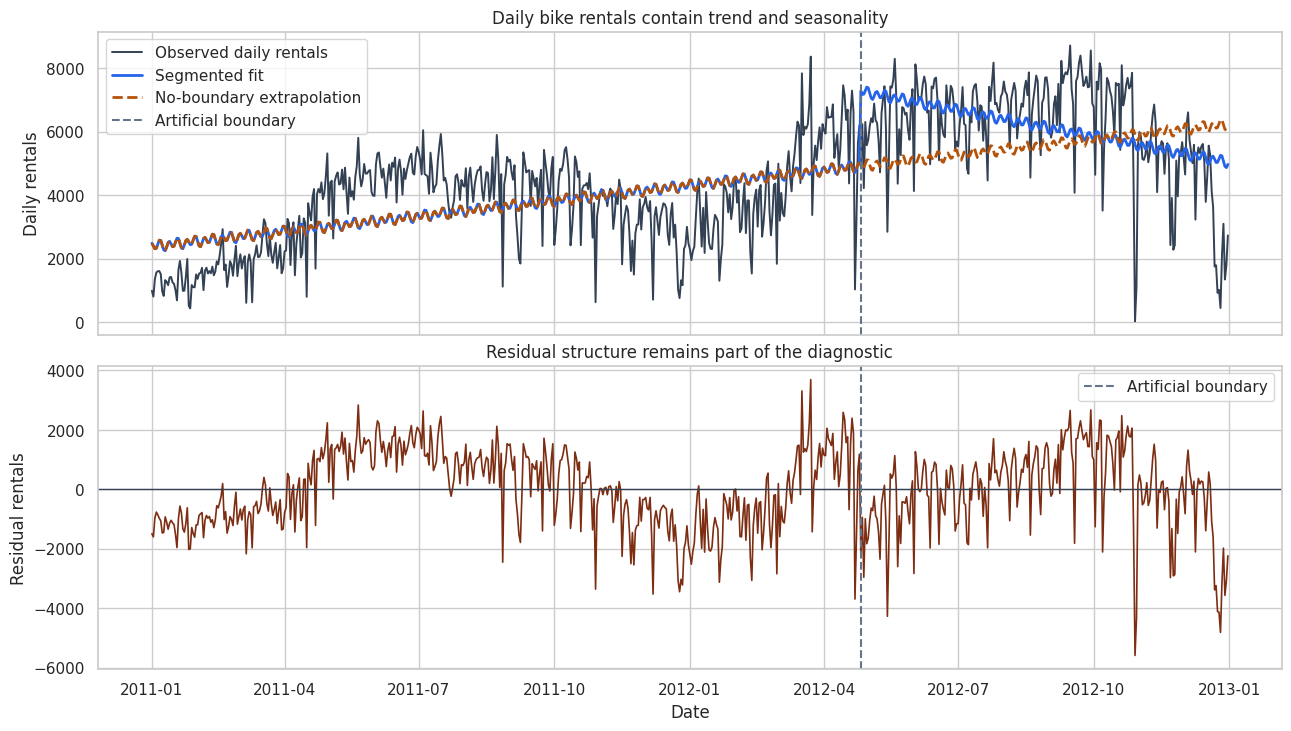

In [26]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.real_data import load_uci_bike_sharing, optional_data_note

RUN_REAL_DATA_COMPANION = True
BIKE_SOURCE = "https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset"

if RUN_REAL_DATA_COMPANION:
    bike = load_uci_bike_sharing().copy().sort_values(["dteday", "hr"])
    daily = (
        bike.groupby("dteday")
        .agg(
            cnt=("cnt", "sum"),
            temp=("temp", "mean"),
            hum=("hum", "mean"),
            windspeed=("windspeed", "mean"),
            workingday=("workingday", "mean"),
        )
        .reset_index()
        .sort_values("dteday")
    )
    daily["t"] = np.arange(len(daily))
    daily["month"] = daily["dteday"].dt.month
    artificial_intervention = int(daily["t"].quantile(0.66))

    bike_its = fit_segmented_its(daily, outcome="cnt", intervention_month=artificial_intervention, include_season=True, hac_lags=14)
    bike_terms = bike_its["terms"]
    fitted_active = bike_its["model"].predict(prediction_frame(daily, bike_terms, artificial_intervention, intervention_active=True))
    fitted_counterfactual = bike_its["model"].predict(
        prediction_frame(daily, bike_terms, artificial_intervention, intervention_active=False)
    )

    bike_coefficients = pd.DataFrame(
        [
            coefficient_row("Artificial level change", bike_its["model"], "post"),
            coefficient_row("Artificial slope change", bike_its["model"], "time_after"),
        ]
    )
    smart_display(bike_coefficients.round(3))

    fig, axes = plt.subplots(2, 1, figsize=(12.8, 7.2), sharex=True, constrained_layout=True)
    axes[0].plot(daily["dteday"], daily["cnt"], color="#334155", linewidth=1.4, label="Observed daily rentals")
    axes[0].plot(daily["dteday"], fitted_active, color="#2563eb", linewidth=2.0, label="Segmented fit")
    axes[0].plot(daily["dteday"], fitted_counterfactual, color="#b45309", linewidth=2.0, linestyle="--", label="No-boundary extrapolation")
    axes[0].axvline(daily.loc[artificial_intervention, "dteday"], color="#64748b", linestyle="--", linewidth=1.5, label="Artificial boundary")
    axes[0].set_title("Daily bike rentals contain trend and seasonality")
    axes[0].set_ylabel("Daily rentals")
    axes[0].legend(frameon=True)

    residuals = daily["cnt"] - fitted_active
    axes[1].plot(daily["dteday"], residuals, color="#7c2d12", linewidth=1.2)
    axes[1].axhline(0, color="#334155", linewidth=1)
    axes[1].axvline(daily.loc[artificial_intervention, "dteday"], color="#64748b", linestyle="--", linewidth=1.5, label="Artificial boundary")
    axes[1].set_title("Residual structure remains part of the diagnostic")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Residual rentals")
    axes[1].legend(frameon=True)
    plt.show()
else:
    optional_data_note("UCI Bike Sharing", BIKE_SOURCE, "RUN_REAL_DATA_COMPANION")

The bike-sharing companion shows why ITS is demanding in practice. Even before causal interpretation, we have to model seasonality, check residuals, and explain why the boundary is meaningful.

In a real ITS project, the boundary would come from a policy launch, measurement change, outage, pricing change, or operational intervention. Without that event story, a segmented time-series model is only descriptive.

## References

Lopez Bernal, J., Cummins, S., & Gasparrini, A. (2016). Interrupted time series regression for the evaluation of public health interventions: A tutorial. *International Journal of Epidemiology*. [https://doi.org/10.1093/ije/dyw098](https://doi.org/10.1093/ije/dyw098)

Penfold, R. B., & Zhang, F. (2013). Use of interrupted time series analysis in evaluating health care quality improvements. *Academic Pediatrics, 13*(6), S38-S44. [https://doi.org/10.1016/j.acap.2013.08.002](https://doi.org/10.1016/j.acap.2013.08.002)

Slavova, S., Costich, J. F., Luu, H., et al. (2018). Interrupted time series design to evaluate the effect of the ICD-9-CM to ICD-10-CM coding transition on injury hospitalization trends. *Injury Epidemiology, 5*, 36. [https://doi.org/10.1186/s40621-018-0165-8](https://doi.org/10.1186/s40621-018-0165-8)

Taljaard, M., McKenzie, J. E., Ramsay, C. R., & Grimshaw, J. M. (2014). The use of segmented regression in analysing interrupted time series studies: An example in pre-hospital ambulance care. *Implementation Science, 9*, 77. [https://doi.org/10.1186/1748-5908-9-77](https://doi.org/10.1186/1748-5908-9-77)

Wagner, A. K., Soumerai, S. B., Zhang, F., & Ross-Degnan, D. (2002). Segmented regression analysis of interrupted time series studies in medication use research. *Journal of Clinical Pharmacy and Therapeutics, 27*(4), 299-309. [https://doi.org/10.1046/j.1365-2710.2002.00430.x](https://doi.org/10.1046/j.1365-2710.2002.00430.x)